# RNN, LSTM, and GRU for Sequential Data

**Unit:** Unit 4: Neural Networks Fundamentals

Every network we have trained so far looks at one *snapshot* — an image, a row of features — and forgets it immediately. But many real signals are *sequences* where order carries the meaning: sensor readings, stock prices, words in a sentence. To predict what comes next, a network needs **memory** of what came before. Recurrent networks add exactly that: a hidden state passed from one time step to the next. In `02_cnn_rnn_architectures.ipynb` we only printed these architectures' summaries; here we actually train the three classic recurrent cells — SimpleRNN, LSTM, and GRU — on the *same* forecasting task with the *same* hidden size and training budget, and let the measured validation error tell us which memory design works best on this task. The task uses a **real** signal: the hour-by-hour count of 911 emergency calls in Montgomery County, Pennsylvania.

## 📚 Learning Objectives

By completing this notebook, you will:
- Turn a continuous signal into (window -> next value) training sequences
- Explain intuitively what gates add: SimpleRNN vs. LSTM vs. GRU
- Train all three cells under an identical budget and compare validation MSE from actual results
- Read a predictions-vs-truth plot to judge forecast quality beyond a single number

## 🔗 Where this fits

**Builds on:** Unit 4, lesson 02 "Deep Learning Architectures: CNNs and RNNs" — the RNN described there is trained here against LSTM and GRU; all three learn by the Unit 3, lesson 04 recipe: define a loss, then use gradient descent to nudge the parameters.

**Used later in:** Course 08 (AIAT 122) — Unit 3 and Course 07 (AIAT 121) — Unit 4, where the same cells are used for language.

---


## 📥 Inputs & 📤 Outputs

**Inputs:** What we use in this notebook

- A real hourly time series built from `montgomery_911_calls.csv` (already in this repo — no downloads)
- Sliding windows of **40 past hours** used to predict the **call volume in the next hour**

**Outputs:** What you'll see when you run the cells

- Printed dataset sizes and per-model parameter counts
- A table of final validation MSE for SimpleRNN, LSTM, and GRU
- One plot overlaying the three models' predictions against the true signal

---

Real series: 2000 consecutive hours, 2015-12-10 14:00 -> 2016-03-02 21:00
Calls per hour: min 0, mean 16.6, max 107
Correlation with the same hour yesterday (lag 24): 0.537  <- a real daily rhythm

Training windows:  1568  (each is 40 hours -> predict hour 41)
Validation windows:  392  (the held-out later weeks)


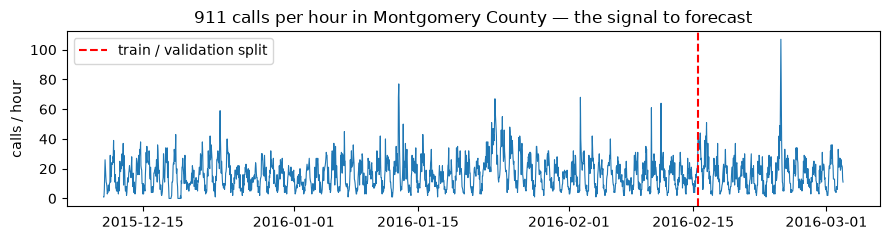

In [1]:
# Setup a forecasting task on a REAL signal: how many 911 emergency calls arrive in
# Montgomery County each hour. We cut it into sliding windows of 40 past hours -> predict
# hour 41. Note the TIME-ORDERED split: we validate on the future, never on shuffled rows.
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras

tf.get_logger().setLevel("ERROR")  # hide harmless tf.function retracing notices
keras.utils.set_random_seed(42)  # reproducible runs

# Read ONE column from the 123 MB call log — that is all a volume forecast needs.
calls = pd.read_csv("../../../Course 04/datasets/raw/montgomery_911_calls.csv",
                    usecols=["timeStamp"], nrows=400_000)
stamps = pd.to_datetime(calls["timeStamp"], errors="coerce").dropna().sort_values()

# Count the calls that arrived in each clock hour, then fill any missing hour with 0
# so the series sits on a complete, evenly spaced hourly grid (recurrent nets assume that).
hourly = stamps.dt.floor("h").value_counts().sort_index().asfreq("h", fill_value=0)

HOURS = 2000                      # about 83 consecutive days — classroom-sized
hourly = hourly.iloc[:HOURS]
raw_series = hourly.to_numpy(dtype="float64")
timeline = hourly.index

print(f"Real series: {len(raw_series)} consecutive hours, "
      f"{timeline[0]:%Y-%m-%d %H:%M} -> {timeline[-1]:%Y-%m-%d %H:%M}")
print(f"Calls per hour: min {raw_series.min():.0f}, mean {raw_series.mean():.1f}, "
      f"max {raw_series.max():.0f}")
print(f"Correlation with the same hour yesterday (lag 24): "
      f"{np.corrcoef(raw_series[:-24], raw_series[24:])[0, 1]:.3f}  <- a real daily rhythm")

# Sliding windows: 40 past hours -> predict the next hour
WINDOW = 40

# Time-ordered split: train on the first 80% of windows, validate on the last 20%.
n_windows = len(raw_series) - WINDOW
n_train = int(0.8 * n_windows)

# Standardize using ONLY the training portion. WHY: the validation hours are the
# "future" — using their mean/std would leak information we would not have in production.
split_point = n_train + WINDOW
mu, sigma = raw_series[:split_point].mean(), raw_series[:split_point].std()
series = (raw_series - mu) / sigma

X = np.array([series[i : i + WINDOW] for i in range(n_windows)])[..., None].astype("float32")
y = np.array([series[i + WINDOW] for i in range(n_windows)]).astype("float32")

X_train, y_train = X[:n_train], y[:n_train]
X_val, y_val = X[n_train:], y[n_train:]

print(f"\nTraining windows:  {len(X_train)}  (each is {WINDOW} hours -> predict hour {WINDOW + 1})")
print(f"Validation windows:{len(X_val):5d}  (the held-out later weeks)")

plt.figure(figsize=(9, 2.5))
plt.plot(timeline, raw_series, lw=0.8)
plt.axvline(timeline[split_point], color="red", ls="--", label="train / validation split")
plt.title("911 calls per hour in Montgomery County — the signal to forecast")
plt.ylabel("calls / hour")
plt.legend()
plt.tight_layout()
plt.show()

## Three ways to remember: SimpleRNN, LSTM, GRU

All three cells read the window one step at a time, carrying a hidden state forward. They differ in *how* that memory is managed:

- **SimpleRNN** — one memory vector, **overwritten at every step** (`new state = f(input, old
  state)`). There is no mechanism to protect old information, so what happened 40 steps ago has
  been rewritten 40 times and mostly fades away (the *vanishing gradient* problem from the
  lectures).
- **LSTM** — adds a separate *cell state* that flows through time like a conveyor belt, plus
  three **gates** (small learned valves outputting 0-1): the **forget gate** decides what to
  erase from the belt, the **input gate** decides what new information to write onto it, and the
  **output gate** decides how much of the belt to reveal at this step. Because information can
  ride the belt untouched, long-range patterns survive.
- **GRU** — the economy version of the LSTM: two gates instead of three (an **update gate**
  merging forget+input into one "keep old vs. take new" dial, and a **reset gate** controlling
  how much history feeds the new candidate). Fewer parameters, often similar quality.

**The experiment:** identical data, identical hidden size (32 units), identical epochs, optimizer, and batch size — the *only* change is the recurrent cell. Note honestly: same hidden width does **not** mean same parameter count, because the gates are extra weights; the printed counts below show it.

One thing real data adds: the series is **standardized**, so an MSE of 1.0 would mean "no better than always predicting the average hour". Anything well below 1.0 is real forecasting skill.

In [2]:
# The fair comparison: SimpleRNN vs LSTM vs GRU in the SAME architecture, same data,
# same epochs — so the recurrent cell type is the only variable.
def build_model(cell_class):
    """Same architecture for all three: one recurrent layer (32 units) + linear output."""
    model = keras.Sequential(
        [keras.Input(shape=(WINDOW, 1)), cell_class(32), keras.layers.Dense(1)]
    )
    model.compile(optimizer="adam", loss="mse")
    return model

cells_to_test = [
    ("SimpleRNN", keras.layers.SimpleRNN),
    ("LSTM", keras.layers.LSTM),
    ("GRU", keras.layers.GRU),
]

EPOCHS = 15
results = {}
for name, cell_class in cells_to_test:
    keras.utils.set_random_seed(42)  # identical init/shuffling conditions for each model
    model = build_model(cell_class)
    model.fit(X_train, y_train, validation_data=(X_val, y_val),
              epochs=EPOCHS, batch_size=32, verbose=0)
    val_mse = model.evaluate(X_val, y_val, verbose=0)
    results[name] = {"model": model, "params": model.count_params(), "val_mse": val_mse}
    print(f"{name:9s} trained: {model.count_params():5,} parameters, "
          f"final val MSE = {val_mse:.4f}  ({EPOCHS} epochs)")

SimpleRNN trained: 1,121 parameters, final val MSE = 0.5224  (15 epochs)


LSTM      trained: 4,385 parameters, final val MSE = 0.5187  (15 epochs)


GRU       trained: 3,393 parameters, final val MSE = 0.5128  (15 epochs)


=== Final validation MSE, standardized units (same data, 32 units, 15 epochs each) ===
model        params   val MSE
GRU           3,393    0.5128
LSTM          4,385    0.5187
SimpleRNN     1,121    0.5224

Best on this run: GRU (val MSE 0.5128)

Baseline 'always predict the training average': val MSE 1.2382
Baseline 'repeat the previous hour'            : val MSE 0.6673
All three recurrent cells beat both baselines — the daily rhythm really is learnable.


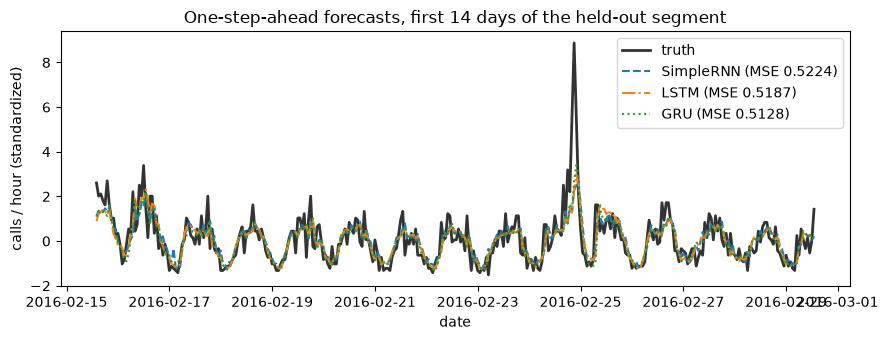

In [3]:
# Results: rank the three cells by validation MSE, then overlay their forecasts on
# the true held-out signal to see the errors, not just read them.
# One table of final validation MSE, ranked best (lowest) first
print("=== Final validation MSE, standardized units (same data, 32 units, 15 epochs each) ===")
print(f"{'model':<10} {'params':>8} {'val MSE':>9}")
ranked = sorted(results.items(), key=lambda kv: kv[1]["val_mse"])
for name, r in ranked:
    print(f"{name:<10} {r['params']:>8,} {r['val_mse']:>9.4f}")
print(f"\nBest on this run: {ranked[0][0]} (val MSE {ranked[0][1]['val_mse']:.4f})")

# Two baselines every forecaster must beat before anyone is allowed to be impressed.
# WHY: on real data a good-looking MSE means nothing until you know what "doing nothing" scores.
mse_mean = float(np.mean((y_val - 0.0) ** 2))              # always predict the training average
mse_persist = float(np.mean((y_val - X_val[:, -1, 0]) ** 2))  # repeat the previous hour
print(f"\nBaseline 'always predict the training average': val MSE {mse_mean:.4f}")
print(f"Baseline 'repeat the previous hour'            : val MSE {mse_persist:.4f}")
print(f"All three recurrent cells beat both baselines — the daily rhythm really is learnable.")

# One plot: the three models' one-step-ahead predictions vs. the true signal
# Predict the whole validation segment with each model for the overlay plot.
preds = {name: r["model"].predict(X_val, verbose=0).ravel() for name, r in results.items()}
t_val = timeline[n_train + WINDOW :]

# Show the first two weeks of the validation segment: the whole span would be an unreadable smear.
show = 24 * 14
plt.figure(figsize=(9, 3.5))
plt.plot(t_val[:show], y_val[:show], "k-", lw=2, label="truth", alpha=0.8)
for (name, p), style in zip(preds.items(), ["--", "-.", ":"]):
    plt.plot(t_val[:show], p[:show], style, lw=1.5,
             label=f"{name} (MSE {results[name]['val_mse']:.4f})")
plt.title("One-step-ahead forecasts, first 14 days of the held-out segment")
plt.xlabel("date")
plt.ylabel("calls / hour (standardized)")
plt.legend()
plt.tight_layout()
plt.show()

### What the numbers say

**On this run the GRU won**, with a final validation MSE of **0.5128**, followed by the LSTM (**0.5187**) and the SimpleRNN (**0.5224**). Four honest readings of that table:

1. **All three genuinely forecast.** Predicting the training average every hour scores **1.2382**
   on the held-out weeks, and simply repeating the previous hour's count scores **0.6673**. Every
   recurrent cell beats both, so the daily rhythm of emergency calls really is learnable —
   the models are not just echoing the last value back at us.
2. **The margin between the three cells is tiny — about 1% — and that is expected here.** Everything
   the models need (yesterday evening's peak, last night's trough) fits inside the 40-hour input
   window. That is exactly the regime a gate-free SimpleRNN can still handle, which is why it stays
   within striking distance of the LSTM at a quarter of the parameters (**1,121 vs. 4,385**). Gates
   earn their cost on *longer* sequences with *long-range* dependencies — remembering something from
   hundreds of steps ago, as in text — where a SimpleRNN's constantly overwritten memory collapses.
3. **The residual error is real-world unpredictability, not a training failure.** Roughly half the
   hour-to-hour variance in 911 volume is genuinely unforecastable: a car crash or a house fire is
   not announced by the previous 40 hours. Compare that with a textbook sine wave, where the only
   thing standing between a model and MSE 0 is noise the author added on purpose. A model that
   drove this validation MSE to 0 would be a warning sign, not a triumph.
4. **Rankings this close are fragile.** With a different seed, a different 2,000-hour slice, or a
   different epoch budget the ordering can shuffle. The durable lesson is not "GRU is always best"
   — it is the *mechanism*: gated cells can protect information across many steps, while a
   SimpleRNN rewrites its entire memory at every step.

## 📚 References

1. Elman, J. L. (1990). *Finding Structure in Time*. Cognitive Science, 14(2), 179–211.
2. Hochreiter, S., & Schmidhuber, J. (1997). *Long Short-Term Memory*. Neural Computation, 9(8), 1735–1780.
3. Cho, K., van Merriënboer, B., Gulcehre, C., et al. (2014). *Learning Phrase Representations using RNN Encoder–Decoder for Statistical Machine Translation* (GRU). EMNLP. <https://arxiv.org/abs/1406.1078>
4. Gu, A., & Dao, T. (2023). *Mamba: Linear-Time Sequence Modeling with Selective State Spaces*. arXiv. <https://arxiv.org/abs/2312.00752>